huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

Extracted 12675 unique seen full names.
Sample Seen Names: ["Trisha Brown's", 'Easy BBQ', 'Maze Runner', 'Alec Taylor', 'Duncan Main']
Generated 1700 synthetic Brazilian full names.
Sample Brazilian Names: ['Henry Gabriel Nunes', 'Alice Alves', 'Melissa Câmara', 'Raquel Barros', 'Luara Farias']
Generated 1700 synthetic full names.
Synthetic Names: ['Henry Gabriel Nunes', 'Alice Alves', 'Melissa Câmara', 'Raquel Barros', 'Luara Farias']
Available Splits: ['WikiMIA_length32', 'WikiMIA_length64', 'WikiMIA_length128', 'WikiMIA_length256']


Extracting from WikiMIA_length256: 100%|██████████| 186/186 [00:03<00:00, 51.32it/s]


Extracted 1775 unique reference full names.
Sample Reference Names: ['Michael Smith', 'David Lemieux', 'Desert Trip', 'Manasseh Sogavare', 'Casey Kopua']


MIN-K++ Unseen: 100%|██████████| 500/500 [00:14<00:00, 34.69it/s]


TPFS AUC: 0.5608
Min-K% AUC: 0.6078
Min-K++ AUC: 0.6139


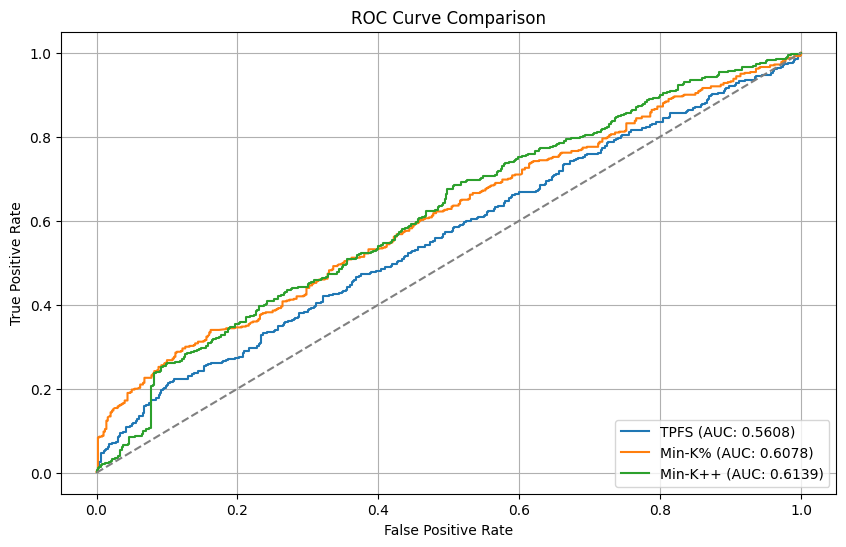

In [7]:
!pip install torch transformers datasets tqdm spacy faker numpy matplotlib 
!python -m spacy download en_core_web_sm
import torch
from datasets import load_dataset
from tqdm import tqdm
import spacy
from faker import Faker
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM

nlp = spacy.load("en_core_web_sm")

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load Bloom 1.7B model and tokenizer
model_name = "EleutherAI/pythia-2.8b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval().cuda()



# Dataset and Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = load_dataset("stas/openwebtext-10k", split="train")

def extract_full_names(text):
    doc = nlp(text[:1000])  # Limit text to 1000 characters for faster processing
    full_names = []
    for ent in doc.ents:
        if ent.label_ == "PERSON" and len(ent.text.split()) == 2:  # First and Last Name
            full_names.append(ent.text)
    return full_names

# Extract names from seen data
seen_full_names = []
for text in tqdm(dataset['text'], desc="Extracting Names from Seen Data"):
    seen_full_names.extend(extract_full_names(text))
seen_full_names = list(set(seen_full_names))
print(f"Extracted {len(seen_full_names)} unique seen full names.")
print("Sample Seen Names:", seen_full_names[:5])
# Brazilian names
fake_br = Faker("pt_BR")  # Portuguese (Brazil)
# Chinese names in English
fake_cn = Faker("zh_CN")  # Chinese locale

def generate_synthetic_rare_names(num_samples, locale):
    if locale == "br":
        fake = fake_br
    elif locale == "cn":
        fake = fake_cn
    else:
        raise ValueError("Locale not supported. Use 'br' for Brazilian or 'cn' for Chinese.")
    
    names = []
    for _ in range(num_samples):
        first_name = fake.first_name()
        last_name = fake.last_name()
        # Combine first and last name
        names.append(f"{first_name} {last_name}")
    return names

# Generate Brazilian names
synthetic_brazilian_names = generate_synthetic_rare_names(1700, "br")
print(f"Generated {len(synthetic_brazilian_names)} synthetic Brazilian full names.")
print("Sample Brazilian Names:", synthetic_brazilian_names[:5])

synthetic_full_names =  synthetic_brazilian_names
print(f"Generated {len(synthetic_full_names)} synthetic full names.")
print("Synthetic Names:", synthetic_full_names[:5])
from datasets import get_dataset_split_names

available_splits = get_dataset_split_names("wjfu99/WikiMIA-24")
print("Available Splits:", available_splits)
wiki_mia_splits = ["WikiMIA_length32", "WikiMIA_length64", "WikiMIA_length128", "WikiMIA_length256"]
reference_names = []

for split in wiki_mia_splits:
    wiki_dataset = load_dataset("wjfu99/WikiMIA-24", split=split)  # Use the split directly
    for text in tqdm(wiki_dataset['input'], desc=f"Extracting from {split}"):  # Access 'input' column
        reference_names.extend(extract_full_names(text))

reference_names = list(set(reference_names))
print(f"Extracted {len(reference_names)} unique reference full names.")
print("Sample Reference Names:", reference_names[:5])
unseen_data_limited = synthetic_full_names[:500]
reference_limited = reference_names
seen_data_limited = seen_full_names[:500]
def get_token_probabilities(model, tokenizer, text):
    tokens = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**tokens, labels=tokens["input_ids"])
        log_probs = torch.log_softmax(outputs.logits, dim=-1)
    token_probs = [log_probs[0, i, tid].item() for i, tid in enumerate(tokens["input_ids"][0])]
    return token_probs

def compute_token_frequency_distribution(reference_texts, tokenizer):
    token_counts = Counter()
    total_tokens = 0

    for text in tqdm(reference_texts, desc="Processing Reference Texts"):
        tokens = tokenizer(text, return_tensors="pt")["input_ids"].squeeze().tolist()
        token_counts.update(tokens)
        total_tokens += len(tokens)

    vocab_size = len(tokenizer)
    token_freqs = {token: (count + 1) / (total_tokens + vocab_size) for token, count in token_counts.items()}
    return token_freqs


# Step 3: Log-Odds Calculation
def calculate_log_odds(token_probs, token_ids, token_freqs):
    log_odds_scores = []
    for prob, token_id in zip(token_probs, token_ids):
        frequency = token_freqs.get(token_id, 1 / len(token_freqs))
        log_odds = -prob * np.log(frequency)
        log_odds_scores.append(log_odds)
    return log_odds_scores

# Step 4: Scoring
def aggregate_scores(log_odds_scores):
    return np.mean(log_odds_scores)

# Full Method Implementation
def evaluate_log_odds_method(model, tokenizer, texts, token_freqs):
    scores = []
    for text in tqdm(texts, desc="Calculating Log-Odds Scores"):
        tokens = tokenizer(text, return_tensors="pt").to(model.device)
        token_ids = tokens["input_ids"].squeeze().tolist()
        token_probs = get_token_probabilities(model, tokenizer, text)
        log_odds_scores = calculate_log_odds(token_probs, token_ids, token_freqs)
        score = aggregate_scores(log_odds_scores)
        scores.append(score)
    return scores
token_freqs = compute_token_frequency_distribution(reference_limited, tokenizer)
seen_scores_tpfs = evaluate_log_odds_method(model, tokenizer, seen_data_limited, token_freqs)
unseen_scores_tpfs = evaluate_log_odds_method(model, tokenizer, unseen_data_limited, token_freqs)
def calculate_min_k_prob(model, tokenizer, text, k_percent=20):
    tokens = tokenizer(text, return_tensors="pt").to(device)['input_ids'].squeeze()
    with torch.no_grad():
        outputs = model(input_ids=tokens.unsqueeze(0))
        log_probs = torch.log_softmax(outputs.logits, dim=-1)

    token_probs = [log_probs[0, i, tok.item()].item() for i, tok in enumerate(tokens)]
    k = max(1, int(len(token_probs) * k_percent / 100))
    return np.mean(sorted(token_probs)[:k])

def calculate_min_k_plus(model, tokenizer, text, k_percent=20):
    tokens = tokenizer(text, return_tensors="pt").to(device)['input_ids'].squeeze()
    with torch.no_grad():
        outputs = model(input_ids=tokens.unsqueeze(0))
        log_probs = torch.log_softmax(outputs.logits, dim=-1)

    token_probs = [log_probs[0, i, tok.item()].item() for i, tok in enumerate(tokens)]
    mean_prob = np.mean(token_probs)
    std_prob = np.std(token_probs)
    normalized_probs = [(p - mean_prob) / (std_prob + 1e-8) for p in token_probs]
    k = max(1, int(len(normalized_probs) * k_percent / 100))
    return np.mean(sorted(normalized_probs)[:k])

seen_scores_mink = [calculate_min_k_prob(model, tokenizer, sample) for sample in tqdm(seen_data_limited, desc="MIN-K% Seen")]
unseen_scores_mink = [calculate_min_k_prob(model, tokenizer, sample) for sample in tqdm(unseen_data_limited, desc="MIN-K% Unseen")]

seen_scores_mink_plus = [calculate_min_k_plus(model, tokenizer, sample) for sample in tqdm(seen_data_limited, desc="MIN-K++ Seen")]
unseen_scores_mink_plus = [calculate_min_k_plus(model, tokenizer, sample) for sample in tqdm(unseen_data_limited, desc="MIN-K++ Unseen")]
import matplotlib.pyplot as plt

def manual_roc_auc(seen_scores, unseen_scores):
    # Combine scores and labels
    scores = seen_scores + unseen_scores
    labels = [1] * len(seen_scores) + [0] * len(unseen_scores)
    
    # Sort scores and labels together by scores in descending order
    combined = sorted(zip(scores, labels), key=lambda x: x[0], reverse=True)
    
    # Initialize variables
    tp = 0
    fp = 0
    fn = sum(labels)  # Total positives
    tn = len(labels) - fn  # Total negatives
    
    tpr = []
    fpr = []
    prev_score = None
    
    for score, label in combined:
        if prev_score is not None and score != prev_score:
            # Append current TPR and FPR to lists
            tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        
        # Update counts based on label
        if label == 1:  # True Positive
            tp += 1
            fn -= 1
        else:  # False Positive
            fp += 1
            tn -= 1
        
        prev_score = score
    
    # Final TPR/FPR for the last threshold
    tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    
    # Calculate AUC using the trapezoidal rule
    auc = np.trapz(tpr, fpr)
    
    return auc, tpr, fpr

# Calculate AUC for TPFS, Min-K%, and Min-K++
tpfs_auc, tpfs_tpr, tpfs_fpr = manual_roc_auc(seen_scores_tpfs, unseen_scores_tpfs)
mink_auc, mink_tpr, mink_fpr = manual_roc_auc(seen_scores_mink, unseen_scores_mink)
mink_plus_auc, mink_plus_tpr, mink_plus_fpr = manual_roc_auc(seen_scores_mink_plus, unseen_scores_mink_plus)

# Print AUC Scores
print(f"TPFS AUC: {tpfs_auc:.4f}")
print(f"Min-K% AUC: {mink_auc:.4f}")
print(f"Min-K++ AUC: {mink_plus_auc:.4f}")

# Plot ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(tpfs_fpr, tpfs_tpr, label=f"TPFS (AUC: {tpfs_auc:.4f})")
plt.plot(mink_fpr, mink_tpr, label=f"Min-K% (AUC: {mink_auc:.4f})")
plt.plot(mink_plus_fpr, mink_plus_tpr, label=f"Min-K++ (AUC: {mink_plus_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()



MIN-K++ Unseen: 100%|██████████| 500/500 [00:14<00:00, 34.88it/s]


TPFS AUC: 0.5608
Min-K% AUC: 0.5742
Min-K++ AUC: 0.3967


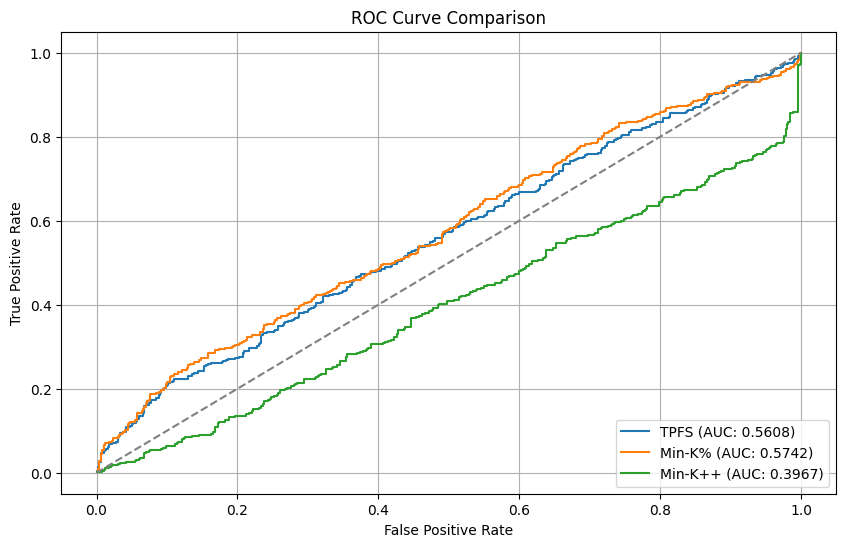

In [8]:
def calculate_min_k_prob(model, tokenizer, text, k_percent=80):
    tokens = tokenizer(text, return_tensors="pt").to(device)['input_ids'].squeeze()
    with torch.no_grad():
        outputs = model(input_ids=tokens.unsqueeze(0))
        log_probs = torch.log_softmax(outputs.logits, dim=-1)

    token_probs = [log_probs[0, i, tok.item()].item() for i, tok in enumerate(tokens)]
    k = max(1, int(len(token_probs) * k_percent / 100))
    return np.mean(sorted(token_probs)[:k])

def calculate_min_k_plus(model, tokenizer, text, k_percent=80):
    tokens = tokenizer(text, return_tensors="pt").to(device)['input_ids'].squeeze()
    with torch.no_grad():
        outputs = model(input_ids=tokens.unsqueeze(0))
        log_probs = torch.log_softmax(outputs.logits, dim=-1)

    token_probs = [log_probs[0, i, tok.item()].item() for i, tok in enumerate(tokens)]
    mean_prob = np.mean(token_probs)
    std_prob = np.std(token_probs)
    normalized_probs = [(p - mean_prob) / (std_prob + 1e-8) for p in token_probs]
    k = max(1, int(len(normalized_probs) * k_percent / 100))
    return np.mean(sorted(normalized_probs)[:k])

seen_scores_mink = [calculate_min_k_prob(model, tokenizer, sample) for sample in tqdm(seen_data_limited, desc="MIN-K% Seen")]
unseen_scores_mink = [calculate_min_k_prob(model, tokenizer, sample) for sample in tqdm(unseen_data_limited, desc="MIN-K% Unseen")]

seen_scores_mink_plus = [calculate_min_k_plus(model, tokenizer, sample) for sample in tqdm(seen_data_limited, desc="MIN-K++ Seen")]
unseen_scores_mink_plus = [calculate_min_k_plus(model, tokenizer, sample) for sample in tqdm(unseen_data_limited, desc="MIN-K++ Unseen")]
import matplotlib.pyplot as plt

def manual_roc_auc(seen_scores, unseen_scores):
    # Combine scores and labels
    scores = seen_scores + unseen_scores
    labels = [1] * len(seen_scores) + [0] * len(unseen_scores)
    
    # Sort scores and labels together by scores in descending order
    combined = sorted(zip(scores, labels), key=lambda x: x[0], reverse=True)
    
    # Initialize variables
    tp = 0
    fp = 0
    fn = sum(labels)  # Total positives
    tn = len(labels) - fn  # Total negatives
    
    tpr = []
    fpr = []
    prev_score = None
    
    for score, label in combined:
        if prev_score is not None and score != prev_score:
            # Append current TPR and FPR to lists
            tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        
        # Update counts based on label
        if label == 1:  # True Positive
            tp += 1
            fn -= 1
        else:  # False Positive
            fp += 1
            tn -= 1
        
        prev_score = score
    
    # Final TPR/FPR for the last threshold
    tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    
    # Calculate AUC using the trapezoidal rule
    auc = np.trapz(tpr, fpr)
    
    return auc, tpr, fpr

# Calculate AUC for TPFS, Min-K%, and Min-K++
tpfs_auc, tpfs_tpr, tpfs_fpr = manual_roc_auc(seen_scores_tpfs, unseen_scores_tpfs)
mink_auc, mink_tpr, mink_fpr = manual_roc_auc(seen_scores_mink, unseen_scores_mink)
mink_plus_auc, mink_plus_tpr, mink_plus_fpr = manual_roc_auc(seen_scores_mink_plus, unseen_scores_mink_plus)

# Print AUC Scores
print(f"TPFS AUC: {tpfs_auc:.4f}")
print(f"Min-K% AUC: {mink_auc:.4f}")
print(f"Min-K++ AUC: {mink_plus_auc:.4f}")

# Plot ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(tpfs_fpr, tpfs_tpr, label=f"TPFS (AUC: {tpfs_auc:.4f})")
plt.plot(mink_fpr, mink_tpr, label=f"Min-K% (AUC: {mink_auc:.4f})")
plt.plot(mink_plus_fpr, mink_plus_tpr, label=f"Min-K++ (AUC: {mink_plus_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()


MIN-K++ Unseen: 100%|██████████| 500/500 [00:14<00:00, 34.32it/s]


TPFS AUC: 0.5608
Min-K% AUC: 0.5791
Min-K++ AUC: 0.5109


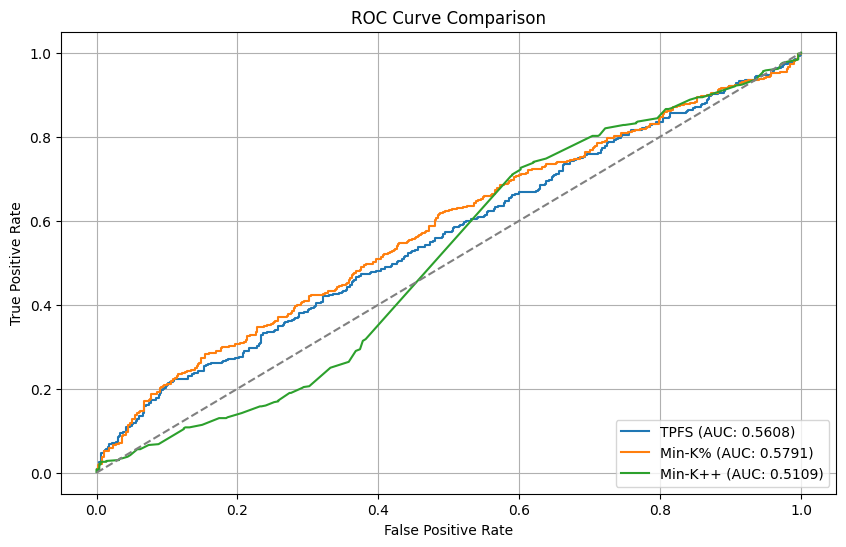

In [9]:
def calculate_min_k_prob(model, tokenizer, text, k_percent=100):
    tokens = tokenizer(text, return_tensors="pt").to(device)['input_ids'].squeeze()
    with torch.no_grad():
        outputs = model(input_ids=tokens.unsqueeze(0))
        log_probs = torch.log_softmax(outputs.logits, dim=-1)

    token_probs = [log_probs[0, i, tok.item()].item() for i, tok in enumerate(tokens)]
    k = max(1, int(len(token_probs) * k_percent / 100))
    return np.mean(sorted(token_probs)[:k])

def calculate_min_k_plus(model, tokenizer, text, k_percent=100):
    tokens = tokenizer(text, return_tensors="pt").to(device)['input_ids'].squeeze()
    with torch.no_grad():
        outputs = model(input_ids=tokens.unsqueeze(0))
        log_probs = torch.log_softmax(outputs.logits, dim=-1)

    token_probs = [log_probs[0, i, tok.item()].item() for i, tok in enumerate(tokens)]
    mean_prob = np.mean(token_probs)
    std_prob = np.std(token_probs)
    normalized_probs = [(p - mean_prob) / (std_prob + 1e-8) for p in token_probs]
    k = max(1, int(len(normalized_probs) * k_percent / 100))
    return np.mean(sorted(normalized_probs)[:k])

seen_scores_mink = [calculate_min_k_prob(model, tokenizer, sample) for sample in tqdm(seen_data_limited, desc="MIN-K% Seen")]
unseen_scores_mink = [calculate_min_k_prob(model, tokenizer, sample) for sample in tqdm(unseen_data_limited, desc="MIN-K% Unseen")]

seen_scores_mink_plus = [calculate_min_k_plus(model, tokenizer, sample) for sample in tqdm(seen_data_limited, desc="MIN-K++ Seen")]
unseen_scores_mink_plus = [calculate_min_k_plus(model, tokenizer, sample) for sample in tqdm(unseen_data_limited, desc="MIN-K++ Unseen")]
import matplotlib.pyplot as plt

def manual_roc_auc(seen_scores, unseen_scores):
    # Combine scores and labels
    scores = seen_scores + unseen_scores
    labels = [1] * len(seen_scores) + [0] * len(unseen_scores)
    
    # Sort scores and labels together by scores in descending order
    combined = sorted(zip(scores, labels), key=lambda x: x[0], reverse=True)
    
    # Initialize variables
    tp = 0
    fp = 0
    fn = sum(labels)  # Total positives
    tn = len(labels) - fn  # Total negatives
    
    tpr = []
    fpr = []
    prev_score = None
    
    for score, label in combined:
        if prev_score is not None and score != prev_score:
            # Append current TPR and FPR to lists
            tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        
        # Update counts based on label
        if label == 1:  # True Positive
            tp += 1
            fn -= 1
        else:  # False Positive
            fp += 1
            tn -= 1
        
        prev_score = score
    
    # Final TPR/FPR for the last threshold
    tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    
    # Calculate AUC using the trapezoidal rule
    auc = np.trapz(tpr, fpr)
    
    return auc, tpr, fpr

# Calculate AUC for TPFS, Min-K%, and Min-K++
tpfs_auc, tpfs_tpr, tpfs_fpr = manual_roc_auc(seen_scores_tpfs, unseen_scores_tpfs)
mink_auc, mink_tpr, mink_fpr = manual_roc_auc(seen_scores_mink, unseen_scores_mink)
mink_plus_auc, mink_plus_tpr, mink_plus_fpr = manual_roc_auc(seen_scores_mink_plus, unseen_scores_mink_plus)

# Print AUC Scores
print(f"TPFS AUC: {tpfs_auc:.4f}")
print(f"Min-K% AUC: {mink_auc:.4f}")
print(f"Min-K++ AUC: {mink_plus_auc:.4f}")

# Plot ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(tpfs_fpr, tpfs_tpr, label=f"TPFS (AUC: {tpfs_auc:.4f})")
plt.plot(mink_fpr, mink_tpr, label=f"Min-K% (AUC: {mink_auc:.4f})")
plt.plot(mink_plus_fpr, mink_plus_tpr, label=f"Min-K++ (AUC: {mink_plus_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [10]:
names = reference_names[:5]

# Tokenize each name and display the tokens
for name in names:
    tokens = tokenizer.tokenize(name)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    print(f"Name: {name}")
    print(f"Tokens: {tokens}")
    print(f"Token IDs: {token_ids}")
    print("-" * 50)


Name: Michael Smith
Tokens: ['Michael', 'ĠSmith']
Token IDs: [18744, 6212]
--------------------------------------------------
Name: David Lemieux
Tokens: ['David', 'ĠLem', 'ieux']
Token IDs: [15418, 6935, 34750]
--------------------------------------------------
Name: Desert Trip
Tokens: ['Des', 'ert', 'ĠTrip']
Token IDs: [4476, 797, 34896]
--------------------------------------------------
Name: Manasseh Sogavare
Tokens: ['Man', 'asse', 'h', 'ĠS', 'og', 'av', 'are']
Token IDs: [4779, 18546, 73, 322, 462, 580, 609]
--------------------------------------------------
Name: Casey Kopua
Tokens: ['Case', 'y', 'ĠK', 'op', 'ua']
Token IDs: [11247, 90, 611, 412, 5738]
--------------------------------------------------
